In [1]:
import numpy as np, camb, local, importlib
from matplotlib.pyplot import *
from scipy.interpolate import RectBivariateSpline

In [2]:
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/rotation/pmf-bispec/local.py'>

In [3]:
# --- CAMB calculation ---
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
lmax = 2000
pars.set_for_lmax(lmax, lens_potential_accuracy=0)
# for all ell, pars.Accuracy.lSampleBoost = 50
data = camb.get_transfer_functions(pars)
transfer = data.get_cmb_transfer_data()
# --- temperature transfer function ---
ells, ks, T_lk = transfer.get_transfer(source=0)
results = camb.get_results(pars)
eta0 = results.conformal_time(0)

In [4]:
T_spline = RectBivariateSpline(ells.astype(float),np.log(ks),T_lk,kx=3,ky=3)
def Delta_T(ell, k):
    ell = np.asarray(ell, dtype=float)
    k = np.asarray(k, dtype=float)
    if np.any(k <= 0):
        raise ValueError("k must be positive.")
    if np.any(k < ks.min()) or np.any(k > ks.max()):
        raise ValueError(f"k is outside CAMB grid: {ks.min()} <= k <= {ks.max()}")
    if np.any(ell < ells.min()) or np.any(ell > ells.max()):
        raise ValueError(f"ell is outside CAMB grid: {ells.min()} <= ell <= {ells.max()}")
    return T_spline.ev(ell, np.log(k))

In [5]:
k_arr = np.logspace(-5,-1,1000)

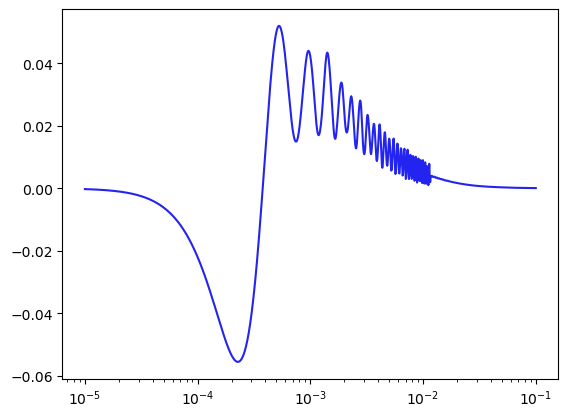

In [6]:
xscale('log')
plot(k_arr,Delta_T(2, k_arr))

In [7]:
r_grid = np.logspace(2,5,50)

In [8]:
Xi = local.Xi_func(2000, r_grid, eta0, -2.9, kn=100)

/global/homes/t/toshiyan/.conda/envs/py_v3_13/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/global/homes/t/toshiyan/.conda/envs/py_v3_13/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


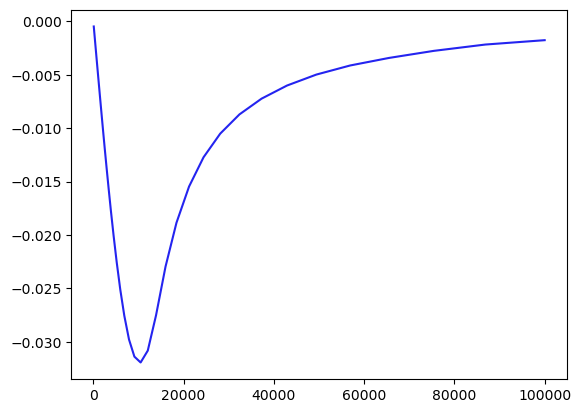

In [9]:
plot(r_grid,Xi[(2,+1)](r_grid))

In [10]:
Upsion = local.Upsilon_func(lmax, r_grid, Delta_T, kn=100)

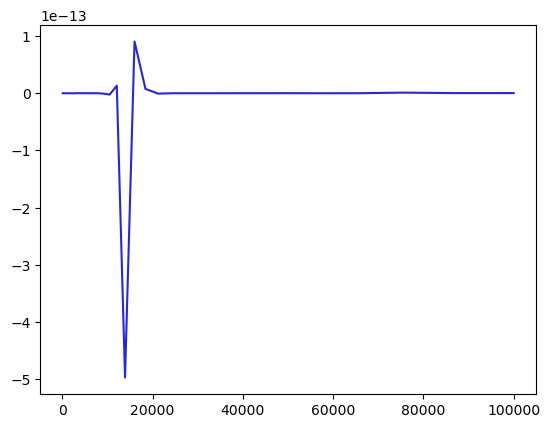

In [11]:
plot(r_grid,Upsion[(12,'L')](r_grid)*Xi[(11,+1)](r_grid)*Xi[(10,0)](r_grid))

In [19]:
l = 2
l1 = 3
l2 = 4
B_val = local.bispec(l,l1,l2,Upsion,Xi,logrmin=2,logrmax=5,rn=100)
print(B_val)
print("real =", B_val.real)
print("imag =", B_val.imag)

0.10511368691739577j
real = 0.0
imag = 0.10511368691739577


In [13]:
from cmblensplus.utils import cmb

In [15]:
ucl = cmb.read_camb_cls('/global/homes/t/toshiyan/Work/Lib/cmblensplus_dev/example/data/unlensedcls.dat',ftype='scal',output='array')[:,:lmax+1]

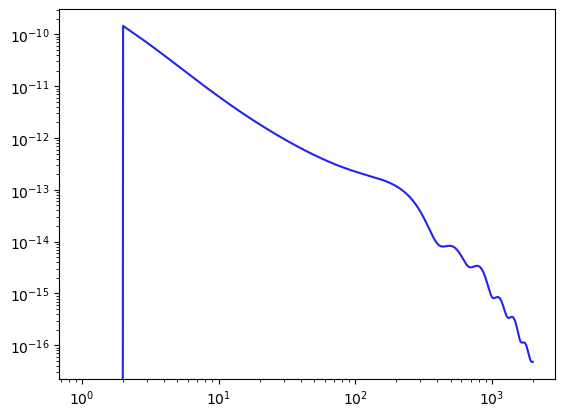

In [18]:
loglog(ucl[0])